
# The Triadic Closure of Existence
## Companion Teaching Notebook

This notebook is a runnable companion to **_The Triadic Closure of Existence: Co-Emergence of Binding, Transformation, and Relational Readout_**.

It is designed to do four things:

1. formalize the paper's core symbols and claims,
2. translate the triad into executable OOP-style abstractions,
3. illustrate the logic of **pairwise insufficiency** with small toy models,
4. show how geometry, rotation, helix structure, and observer recursion can be rendered as local readout languages.

### Scope

This notebook separates three layers:

- **structural claims**: the paper's core grammar,
- **toy demonstrations**: executable models that illustrate the grammar,
- **open conjectures**: directions that are not established proofs.

The notebook does **not** claim to settle force unification experimentally. It stays anchored to the functional triad:

$$
\mathcal{B} = \text{Binding}, \qquad
\mathcal{T} = \text{Transformation}, \qquad
\mathcal{R} = \text{Relational Readout}.
$$

and to the universal implementation claim:

$$
\boxed{
\text{All things implement }(\mathcal{B},\mathcal{T},\mathcal{R})\text{ across a boundary.}
}
$$


In [1]:

# Optional: install extra packages if your environment is minimal.
# Uncomment and run if needed.
# %pip install numpy pandas sympy matplotlib


In [2]:

from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

import math
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("Notebook environment ready.")


Notebook environment ready.



## 1. Symbolic Kernel

We start with the paper's core symbolic objects.

Let:

- $\Gamma$ be a **boundary**,
- $X$ be a local state space,
- $\mathcal{B}$ be the binding operator,
- $\mathcal{T}$ be the transformation operator,
- $\mathcal{R}$ be the readout operator.

The key correction is:

$$
\Gamma \neq \text{gap}.
$$

Instead:

$$
\boxed{
\Gamma = \text{the local interface where the field becomes readable.}
}
$$

The universal closure law is:

$$
\boxed{
\forall S,\quad S \models (\mathcal{B},\mathcal{T},\mathcal{R})\text{ across }\Gamma_S.
}
$$


In [3]:

# Symbolic setup with SymPy
B, T, R = sp.symbols("B T R", commutative=True)
Gamma = sp.Symbol("Gamma")
S = sp.Symbol("S")
Implements = sp.Function("Implements_BTR_across_Gamma")

law = Implements(S)
display(law)


Implements_BTR_across_Gamma(S)


## 2. OOP Base Class

The paper's universal claim becomes especially clean in OOP language:

```python
abstract class Existence:
    bind()
    transform()
    read()
```

That means reality is not a collection of unrelated nouns. It is a family of concrete implementations of one abstract interface.


In [4]:

class ExistenceABC(ABC):
    """Universal interface for triadic closure across a boundary."""

    def __init__(self, name: str, boundary: str):
        self.name = name
        self.boundary = boundary

    @abstractmethod
    def bind(self):
        """Preserve coherence / retain bounded identity."""
        raise NotImplementedError

    @abstractmethod
    def transform(self):
        """Generate lawful change."""
        raise NotImplementedError

    @abstractmethod
    def read(self):
        """Expose distinguishable state across a boundary."""
        raise NotImplementedError


class PhysicalSystem(ExistenceABC):
    def bind(self):
        return "confinement / stability / persistence"

    def transform(self):
        return "interaction / decay / propagation"

    def read(self):
        return "radiative coupling / measurable distinction"


class ChemicalSystem(ExistenceABC):
    def bind(self):
        return "bond stability / molecular coherence"

    def transform(self):
        return "reaction pathway / rearrangement"

    def read(self):
        return "affinity / exchange / legible state difference"


class BiologicalSystem(ExistenceABC):
    def bind(self):
        return "membrane / scaffold / retained form"

    def transform(self):
        return "metabolism / replication / mutation"

    def read(self):
        return "sensing / signaling / expression"


class ObserverSystem(ExistenceABC):
    def bind(self):
        return "memory / self-coherence"

    def transform(self):
        return "updating / inference / internal state change"

    def read(self):
        return "perception / reportability / retained difference"


systems = [
    PhysicalSystem("physics", "field interface"),
    ChemicalSystem("chemistry", "molecular interface"),
    BiologicalSystem("biology", "membrane interface"),
    ObserverSystem("observer", "phenomenal interface"),
]

rows = []
for sys in systems:
    rows.append({
        "system": sys.name,
        "boundary": sys.boundary,
        "bind()": sys.bind(),
        "transform()": sys.transform(),
        "read()": sys.read(),
    })

pd.DataFrame(rows)


,system,boundary,bind(),transform(),read()
0,physics,field interface,confinement / stability / persistence,interaction / decay / propagation,radiative coupling / measurable distinction
1,chemistry,molecular interface,bond stability / molecular coherence,reaction pathway / rearrangement,affinity / exchange / legible state difference
2,biology,membrane interface,membrane / scaffold / retained form,metabolism / replication / mutation,sensing / signaling / expression
3,observer,phenomenal interface,memory / self-coherence,updating / inference / internal state change,perception / reportability / retained difference



## 3. Pairwise Insufficiency

The paper's first hard theorem-shaped object is the claim that no pair of the triad is enough.

Using the paper's language:

- without $\mathcal{B}$: no durable substrate,
- without $\mathcal{T}$: no becoming,
- without $\mathcal{R}$: no observer-compatible exchange.

We can encode that as a compact truth table.


In [5]:

cases = [
    {"B": 1, "T": 1, "R": 1},
    {"B": 1, "T": 1, "R": 0},
    {"B": 1, "T": 0, "R": 1},
    {"B": 0, "T": 1, "R": 1},
    {"B": 1, "T": 0, "R": 0},
    {"B": 0, "T": 1, "R": 0},
    {"B": 0, "T": 0, "R": 1},
]

def outcome(row: Dict[str, int]) -> str:
    Bv, Tv, Rv = row["B"], row["T"], row["R"]
    if Bv and Tv and Rv:
        return "stable-transforming-readable reality"
    if Bv and Tv and not Rv:
        return "structural blindness / silent substrate"
    if Bv and not Tv and Rv:
        return "static crystalline death / frozen substrate"
    if not Bv and Tv and Rv:
        return "incoherent flux / no durable identity"
    if Bv and not Tv and not Rv:
        return "bound but mute stasis"
    if not Bv and Tv and not Rv:
        return "evanescent change without substrate"
    if not Bv and not Tv and Rv:
        return "legible shell without stable interior"
    return "degenerate"

table = pd.DataFrame(cases)
table["outcome"] = table.apply(outcome, axis=1)
table


,B,T,R,outcome
0,1,1,1,stable-transforming-readable reality
1,1,1,0,structural blindness / silent substrate
2,1,0,1,static crystalline death / frozen substrate
3,0,1,1,incoherent flux / no durable identity
4,1,0,0,bound but mute stasis
5,0,1,0,evanescent change without substrate
6,0,0,1,legible shell without stable interior



## 4. A Toy Dynamical Model of the Triad

The next cell is **not** a proof of physics. It is a pedagogical model.

We define a minimal state with three observables:

- coherence,
- internal change,
- external legibility.

The model is constructed so that:

- low $\mathcal{B}$ causes dispersion,
- low $\mathcal{T}$ causes freezing,
- low $\mathcal{R}$ causes unreadability,
- high values of all three sustain a readable evolving state.

This is just a teaching model, but it makes the paper's logic executable.


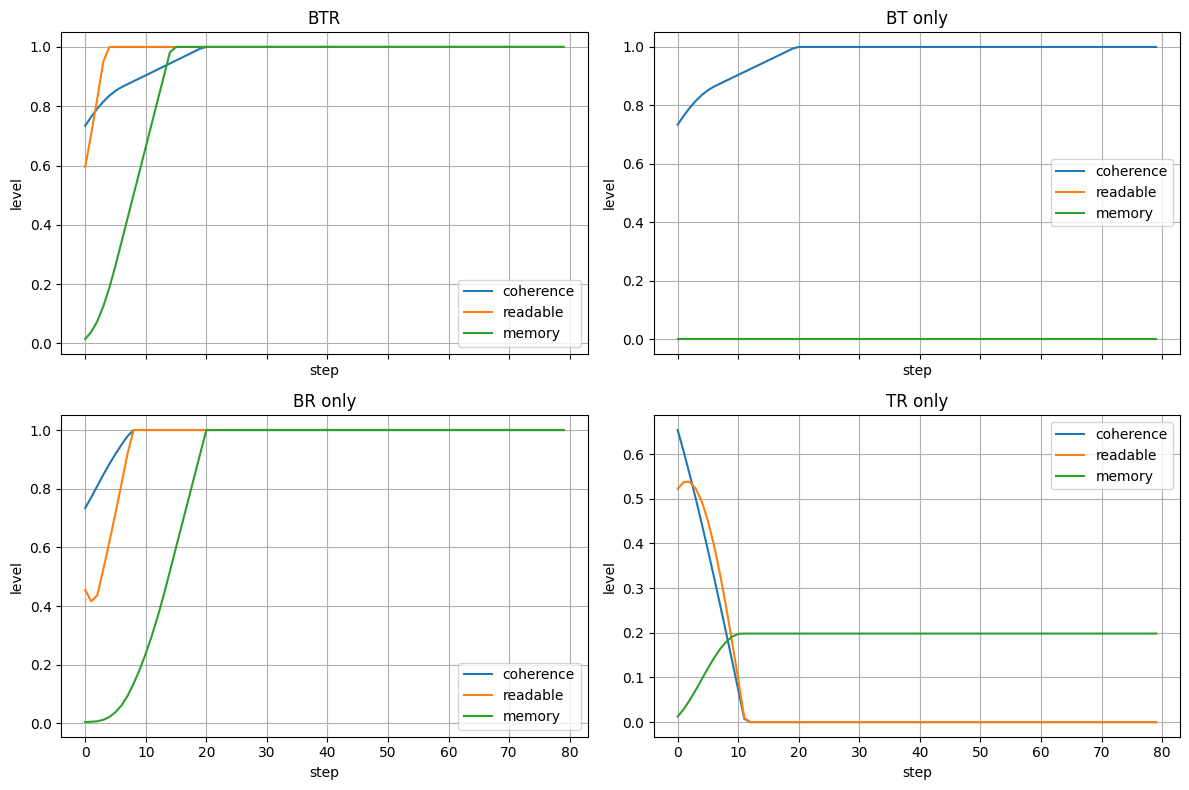

In [6]:

def simulate_system(Bv: float, Tv: float, Rv: float, steps: int = 80) -> pd.DataFrame:
    """
    Small didactic simulator for triadic closure.
    Bv, Tv, Rv are in [0, 1].
    """
    coherence = 0.7
    state = 0.2
    memory = 0.0
    readable = 0.0

    rows = []
    for t in range(steps):
        # Binding retains coherence.
        coherence = np.clip(coherence + 0.08 * (Bv - 0.5) - 0.03 * abs(state), 0.0, 1.0)

        # Transformation updates internal state only if there is enough coherence to carry change.
        state = np.clip(state + 0.15 * Tv * coherence - 0.08 * (1 - Tv), -1.0, 1.0)

        # Readout becomes stronger when coherent structure exists and change can be exposed.
        readable = np.clip(Rv * max(coherence, 0) * (0.5 + abs(state)), 0.0, 1.0)

        # Memory of difference accumulates when readout folds back on changing structure.
        memory = np.clip(memory + 0.08 * readable * abs(state), 0.0, 1.0)

        rows.append({
            "t": t,
            "coherence": coherence,
            "state": state,
            "readable": readable,
            "memory": memory,
        })

    return pd.DataFrame(rows)


scenarios = {
    "BTR": (1.0, 1.0, 1.0),
    "BT only": (1.0, 1.0, 0.0),
    "BR only": (1.0, 0.0, 1.0),
    "TR only": (0.0, 1.0, 1.0),
}

results = {name: simulate_system(*vals) for name, vals in scenarios.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (name, df) in zip(axes.ravel(), results.items()):
    ax.plot(df["t"], df["coherence"], label="coherence")
    ax.plot(df["t"], df["readable"], label="readable")
    ax.plot(df["t"], df["memory"], label="memory")
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylabel("level")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()



### Reading the toy model

The all-three case tends to sustain all three curves together.

The pairwise cases each fail in a different way:

- **BT only** evolves, but cannot expose itself,
- **BR only** remains too static to unfold,
- **TR only** changes and leaks but cannot hold durable identity.

That is the notebook form of the paper's pairwise-insufficiency program.



## 5. Rotating Closure: $Q \leftrightarrow C \leftrightarrow O$

The paper's supplemental section introduces the rotating closure:

$$
Q \leftrightarrow C \leftrightarrow O \leftrightarrow Q
$$

where:

- $Q$ = query / open face,
- $C$ = constraint field / operative face,
- $O$ = object / closed face.

A simple way to illustrate this is to render three phase-shifted oscillations.


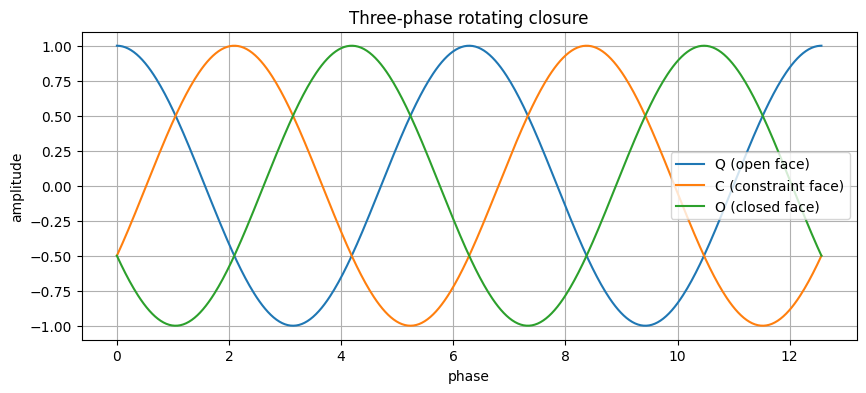

In [7]:

theta = np.linspace(0, 4 * np.pi, 500)
Q = np.cos(theta)
C = np.cos(theta - 2*np.pi/3)
O = np.cos(theta - 4*np.pi/3)

plt.figure(figsize=(10, 4))
plt.plot(theta, Q, label="Q (open face)")
plt.plot(theta, C, label="C (constraint face)")
plt.plot(theta, O, label="O (closed face)")
plt.xlabel("phase")
plt.ylabel("amplitude")
plt.title("Three-phase rotating closure")
plt.legend()
plt.show()



## 6. Geometry as Readout Language

The paper proposes that geometry is one local readout language of closure.

The general metric law is the law of cosines:

$$
c^2 = a^2 + b^2 - 2ab\cos\theta.
$$

Pythagoras is the orthogonal special case:

$$
a^2 + b^2 = c^2
\qquad \text{when} \qquad \theta = \frac{\pi}{2}.
$$

The next cell renders that dependence directly.


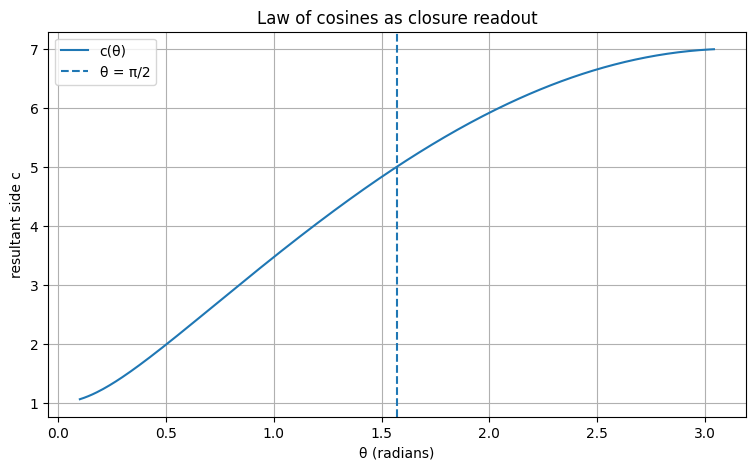

For a=3.0 and b=4.0, the orthogonal special case gives c=5.0000.


In [8]:

a, b = 3.0, 4.0
angles = np.linspace(0.1, np.pi - 0.1, 300)
c = np.sqrt(a**2 + b**2 - 2*a*b*np.cos(angles))

plt.figure(figsize=(9, 5))
plt.plot(angles, c, label="c(θ)")
plt.axvline(np.pi/2, linestyle="--", label="θ = π/2")
plt.xlabel("θ (radians)")
plt.ylabel("resultant side c")
plt.title("Law of cosines as closure readout")
plt.legend()
plt.show()

c_pyth = math.sqrt(a*a + b*b)
print(f"For a={a} and b={b}, the orthogonal special case gives c={c_pyth:.4f}.")



## 7. The Helix of Existence

The paper's main text presents a helix as the propagated geometry of structural coupling through time.

A standard parametric helix is:

$$
\mathbf r(t) = \bigl(r\cos(\omega t),\ r\sin(\omega t),\ vt\bigr).
$$

This lets us separate the three local roles visually:

- radius $r$ = bounded closure,
- angular motion $\omega$ = phase-locked recurrence,
- axial propagation $v$ = developmental advance.

The next cell renders a simple helix.


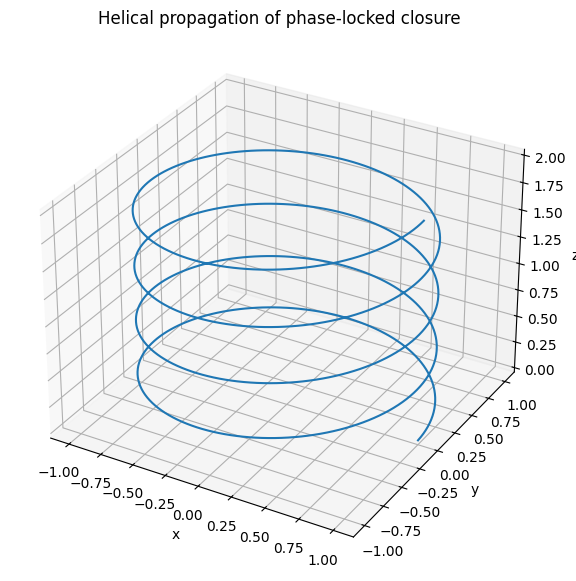

In [9]:

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

t = np.linspace(0, 8*np.pi, 600)
radius = 1.0
omega = 1.0
v = 0.08

x = radius * np.cos(omega * t)
y = radius * np.sin(omega * t)
z = v * t

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x, y, z)
ax.set_title("Helical propagation of phase-locked closure")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()



## 8. Observer Chain

The paper gives an observer-emergence sequence:

$$
\text{need} \to \text{space} \to \text{coupling} \to \text{stability} \to \text{memory of difference}.
$$

We can turn that into a tiny recursive accumulator model where readout folds back into transformation.


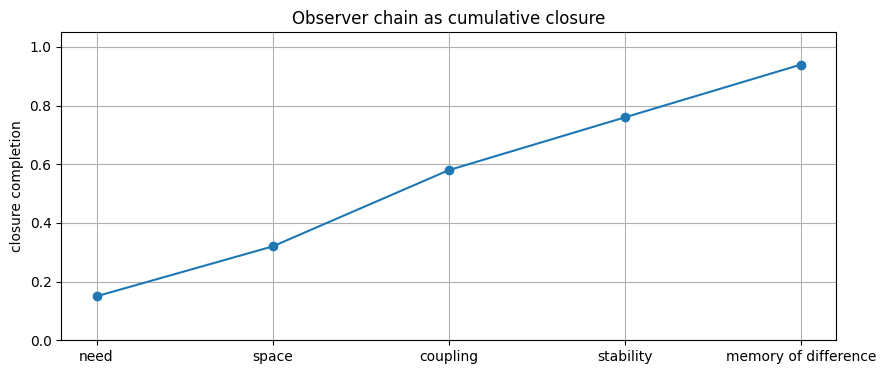

In [10]:

stages = ["need", "space", "coupling", "stability", "memory of difference"]
values = [0.15, 0.32, 0.58, 0.76, 0.94]

plt.figure(figsize=(10, 4))
plt.plot(stages, values, marker="o")
plt.ylim(0, 1.05)
plt.ylabel("closure completion")
plt.title("Observer chain as cumulative closure")
plt.show()


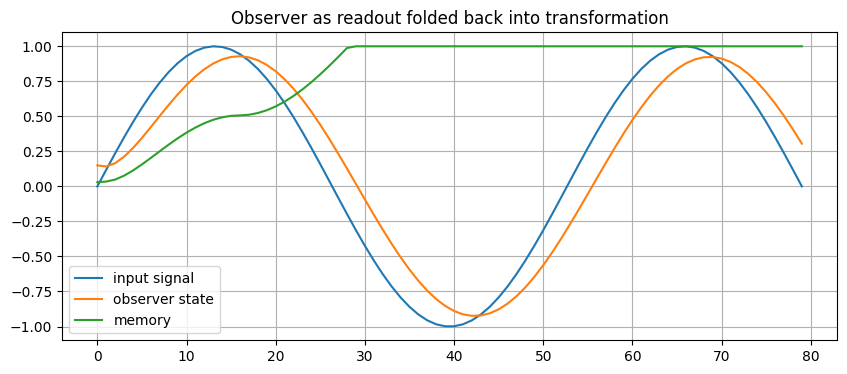

In [11]:

@dataclass
class ObserverClosure:
    state: float = 0.2
    memory: float = 0.0

    def step(self, input_signal: float) -> Tuple[float, float]:
        # Readout of incoming signal.
        readout = abs(input_signal - self.state)

        # Transformation driven by what is read.
        self.state += 0.25 * (input_signal - self.state)

        # Memory of difference accumulates from readable change.
        self.memory += 0.15 * readout
        self.memory = min(self.memory, 1.0)

        return self.state, self.memory


obs = ObserverClosure()
signal = np.sin(np.linspace(0, 3*np.pi, 80))

states, memories = [], []
for s in signal:
    st, mem = obs.step(float(s))
    states.append(st)
    memories.append(mem)

plt.figure(figsize=(10, 4))
plt.plot(signal, label="input signal")
plt.plot(states, label="observer state")
plt.plot(memories, label="memory")
plt.title("Observer as readout folded back into transformation")
plt.legend()
plt.show()



## 9. One Table to Hold the Paper Together

This table compresses the entire paper into a domain-translation view.


In [12]:

summary = pd.DataFrame([
    {
        "domain": "physics",
        "Binding (B)": "confinement / persistence",
        "Transformation (T)": "interaction / decay / change",
        "Readout (R)": "radiation / measurable relation",
        "Boundary": "field interface",
    },
    {
        "domain": "chemistry",
        "Binding (B)": "bond stability",
        "Transformation (T)": "reaction / rearrangement",
        "Readout (R)": "affinity / exchange",
        "Boundary": "molecular interface",
    },
    {
        "domain": "biology",
        "Binding (B)": "scaffold / membrane",
        "Transformation (T)": "replication / metabolism",
        "Readout (R)": "signaling / expression",
        "Boundary": "cellular interface",
    },
    {
        "domain": "observer",
        "Binding (B)": "memory / self-coherence",
        "Transformation (T)": "updating / inference",
        "Readout (R)": "perception / reportability",
        "Boundary": "phenomenal interface",
    },
    {
        "domain": "computation",
        "Binding (B)": "state retention",
        "Transformation (T)": "transition rule",
        "Readout (R)": "output / residue",
        "Boundary": "I/O interface",
    },
])
summary


,domain,Binding (B),Transformation (T),Readout (R),Boundary
0,physics,confinement / persistence,interaction / decay / change,radiation / measurable relation,field interface
1,chemistry,bond stability,reaction / rearrangement,affinity / exchange,molecular interface
2,biology,scaffold / membrane,replication / metabolism,signaling / expression,cellular interface
3,observer,memory / self-coherence,updating / inference,perception / reportability,phenomenal interface
4,computation,state retention,transition rule,output / residue,I/O interface



## 10. Structural Claims vs Open Proof Obligations

### Structural claims this notebook supports

- The triad can be written as a universal interface.
- Pairwise failure can be expressed clearly and executed in toy form.
- The observer can be modeled as readout feeding back into transformation.
- Geometry can be treated as a local readout language of closure.

### Open proof obligations from the paper

1. Make pairwise insufficiency rigorous in full physical detail.
2. Derive the geometry layer more formally from the triadic operator itself.
3. Clarify the relation between the functional triad and the specific physical interactions.
4. Formalize the braid operator dynamically, not only schematically.

The notebook is therefore a **companion runtime**, not a claim that every open proof is already closed.



## 11. Exercises and Extension Prompts

1. Replace the toy simulator with a lattice or cellular automaton and test whether a sharper phase boundary appears when one of $B$, $T$, or $R$ is suppressed.
2. Build a graph-theoretic version of the boundary operator $\Gamma$ and test whether observer-like memory requires explicit feedback edges.
3. Treat the helix cell as a discrete update rule and compare it to a transistor-style base/collector/emitter logic.
4. Extend the notebook by adding the paper's later universal law:

$$
\boxed{
\text{All things implement }(\mathcal B,\mathcal T,\mathcal R)\text{ across a boundary.}
}
$$

and compare that formulation to the earlier force-mapped triad.

---

## Closing compression

$$
\boxed{
\text{A thing is a boundary-closed }(\mathcal B,\mathcal T,\mathcal R)\text{ loop.}
}
$$

$$
\boxed{
\text{An observer is a thing whose readout re-enters its own transform path.}
}
$$

$$
\boxed{
\text{Geometry is one readable face of closure.}
}
$$
